<a href="https://colab.research.google.com/github/Evans-Sense/pet/blob/main/Hometask_3_MLPro2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub
import os
from tqdm import tqdm

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
import umap
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering, DBSCAN

from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import confusion_matrix, classification_report


В этом домашнем задании вам предстоит настроить систему по поиску аномалий в банковских транзакциях. Мало того, что аномальных значений в данных меньше одного процента, так еще и переменные анонимизированные и представляют собой первые 28 главных компонент, полученных после PCA преобразования оригинальных данных (о которых мы ничего не знаем).


# Описание/Пошаговая инструкция выполнения домашнего задания:
Скачайте датасет с https://www.kaggle.com/mlg-ulb/creditcardfraud#creditcard.csv


In [3]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [4]:
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/creditcardfraud/creditcard.csv


In [5]:
df= pd.read_csv('/kaggle/input/creditcardfraud/creditcard.csv')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Проведите небольшой EDA (гистограммы и описательные статистики - обязательно).


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df.drop(['Time', 'Amount', 'Class'], axis=1).hist(bins=50, figsize=(20,20))
plt.suptitle('Histograms of PCA Components', y=1.02, fontsize=24) # Adjust suptitle position and size for larger figure
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to accommodate larger suptitle
plt.show()

In [ ]:
plt.figure(figsize=(20,20))

corr_matrix = df.corr()
lower = corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))

sns.heatmap(lower, annot=True, fmt='.2f', cbar=False, center=0);

In [ ]:
plt.figure(figsize=(10,10))
df['Amount'].plot(kind='box')
plt.title('Distribution of Amount (Boxplot, Log Scale)')
plt.ylabel('Amount (Log Scale)')
plt.yscale('log')
plt.show()

In [ ]:
print(df['Class'].value_counts())

In [ ]:
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, ax=axes[0], color='blue', label='Non-Fraud')
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, ax=axes[0], color='red', label='Fraud')
axes[0].set_title('Distribution of Amount by Class')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_yscale('log')

sns.histplot(df[df['Class'] == 0]['Time'], bins=50, ax=axes[1], color='blue', label='Non-Fraud')
sns.histplot(df[df['Class'] == 1]['Time'], bins=50, ax=axes[1], color='red', label='Fraud')
axes[1].set_title('Distribution of Time by Class')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

# Воспользуйтесь процентом аномалий, подсчитанным по переменной Class, как "экспертной оценкой" загрязненности нашего датасета.


In [ ]:
fraud_count = df['Class'].value_counts()[1]
non_fraud_count = df['Class'].value_counts()[0]
total_count = len(df)

anomaly_percent = (fraud_count / total_count) * 100
print(f"Anomaly percent: {anomaly_percent:.4f}%")

# Попробуйте построить различные модели и алгоритмы, разобранные на занятии, используя полученную экспертную оценку для настройки параметров.


# Sigma

In [14]:
def outlier_std(data, col, threshold=3):
    mean = data[col].mean()
    std = data[col].std()
    up_bound = mean + threshold * std
    low_bound = mean - threshold * std
    anomalies = pd.concat([data[col]>up_bound, data[col]<low_bound], axis=1).any(axis = 1)
    return anomalies, up_bound, low_bound

In [15]:
def get_column_outliers(data, columns=None, function=outlier_std, threshold=18):
    if columns:
        columns_to_check = columns
    else:
        columns_to_check = data.columns

    outliers = pd.Series(data=[False]*len(data), index=data_features.index, name='is_outlier')
    comparison_table = {}
    for column in columns_to_check:
        anomalies, upper_bound, lower_bound = function(data, column, threshold=threshold)
        comparison_table[column] = [upper_bound, lower_bound, sum(anomalies), 100*sum(anomalies)/len(anomalies)]
        outliers[anomalies[anomalies].index] = True

    comparison_table = pd.DataFrame(comparison_table).T
    comparison_table.columns=['upper_bound', 'lower_bound', 'anomalies_count', 'anomalies_percentage']
    comparison_table = comparison_table.sort_values(by='anomalies_percentage', ascending=False)

    return comparison_table, outliers

def anomalies_report(outliers):
    print("Total number of outliers: {}\nPercentage of outliers:   {:.2f}%".format(
            sum(outliers), 100*sum(outliers)/len(outliers)))

In [16]:
data_features = df.iloc[:, :-1]

In [ ]:
anomalies_percent = []
for i in range(3, 20):
  comparison_table, std_outliers = get_column_outliers(data_features, threshold=i)
  anomalies_percent.append(100*sum(std_outliers)/len(std_outliers))

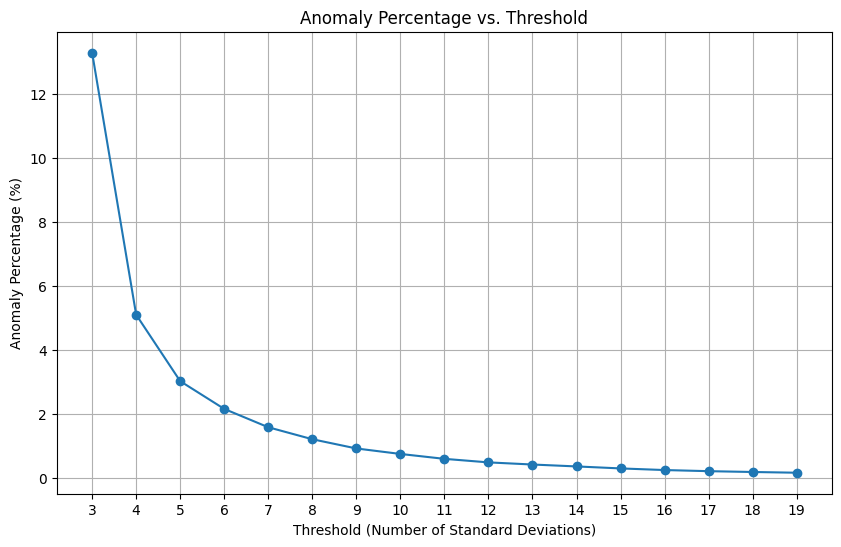

In [ ]:
threshold_values = range(3, 20)
plt.figure(figsize=(10, 6))
plt.plot(list(threshold_values), anomalies_percent, marker='o')
plt.title('Anomaly Percentage vs. Threshold')
plt.xlabel('Threshold (Number of Standard Deviations)')
plt.ylabel('Anomaly Percentage (%)')
plt.grid(True)
plt.xticks(list(threshold_values))
plt.show()

In [ ]:
comparison_table, std_outliers = get_column_outliers(data_features, threshold=18)
anomalies_report(std_outliers)

Total number of outliers: 498
Percentage of outliers:   0.17%


In [ ]:
comparison_table

,upper_bound,lower_bound,anomalies_count,anomalies_percentage
V23,11.240285,-11.240285,114.0,0.040027
V21,13.221432,-13.221432,92.0,0.032303
V28,5.941499,-5.941499,88.0,0.030898
V20,13.876650,-13.876650,85.0,0.029845
V8,21.498352,-21.498352,77.0,0.027036
Amount,4590.511586,-4413.812347,74.0,0.025983
V17,15.288067,-15.288067,73.0,0.025631
V2,29.723554,-29.723554,45.0,0.015800
V7,22.267685,-22.267685,45.0,0.015800
V27,7.265385,-7.265385,33.0,0.011587


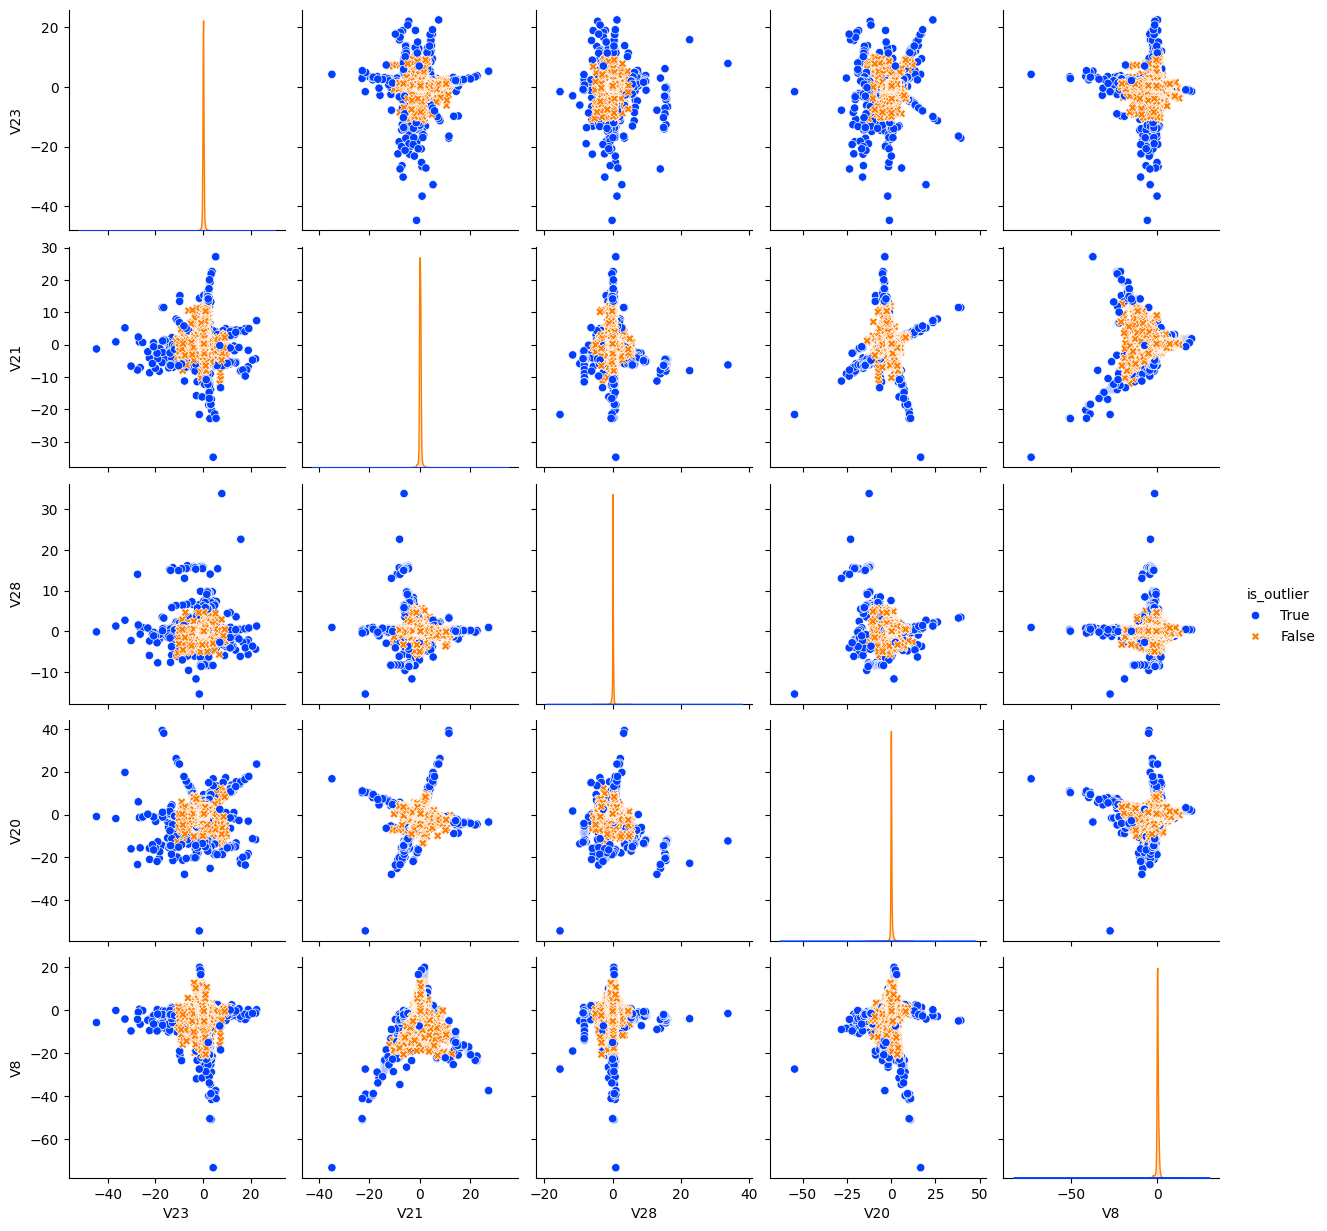

In [ ]:
high_corr = comparison_table.head(5).index.tolist()
labeled_data = data_features[high_corr].copy()
labeled_data['is_outlier'] = std_outliers

sns.pairplot(data=labeled_data, vars=high_corr,
             hue='is_outlier', hue_order=[True, False],
             markers=['X', 'o'], palette='bright');

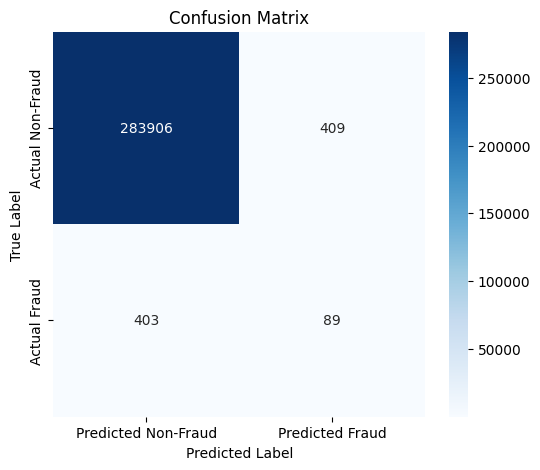


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.18      0.18      0.18       492

    accuracy                           1.00    284807
   macro avg       0.59      0.59      0.59    284807
weighted avg       1.00      1.00      1.00    284807



In [ ]:
predicted_labels = std_outliers.astype(int)

true_labels = df['Class']

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Fraud', 'Predicted Fraud'],
            yticklabels=['Actual Non-Fraud', 'Actual Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print('\nClassification Report:')
print(classification_report(true_labels, predicted_labels))

# **Межквартильное отклонение**

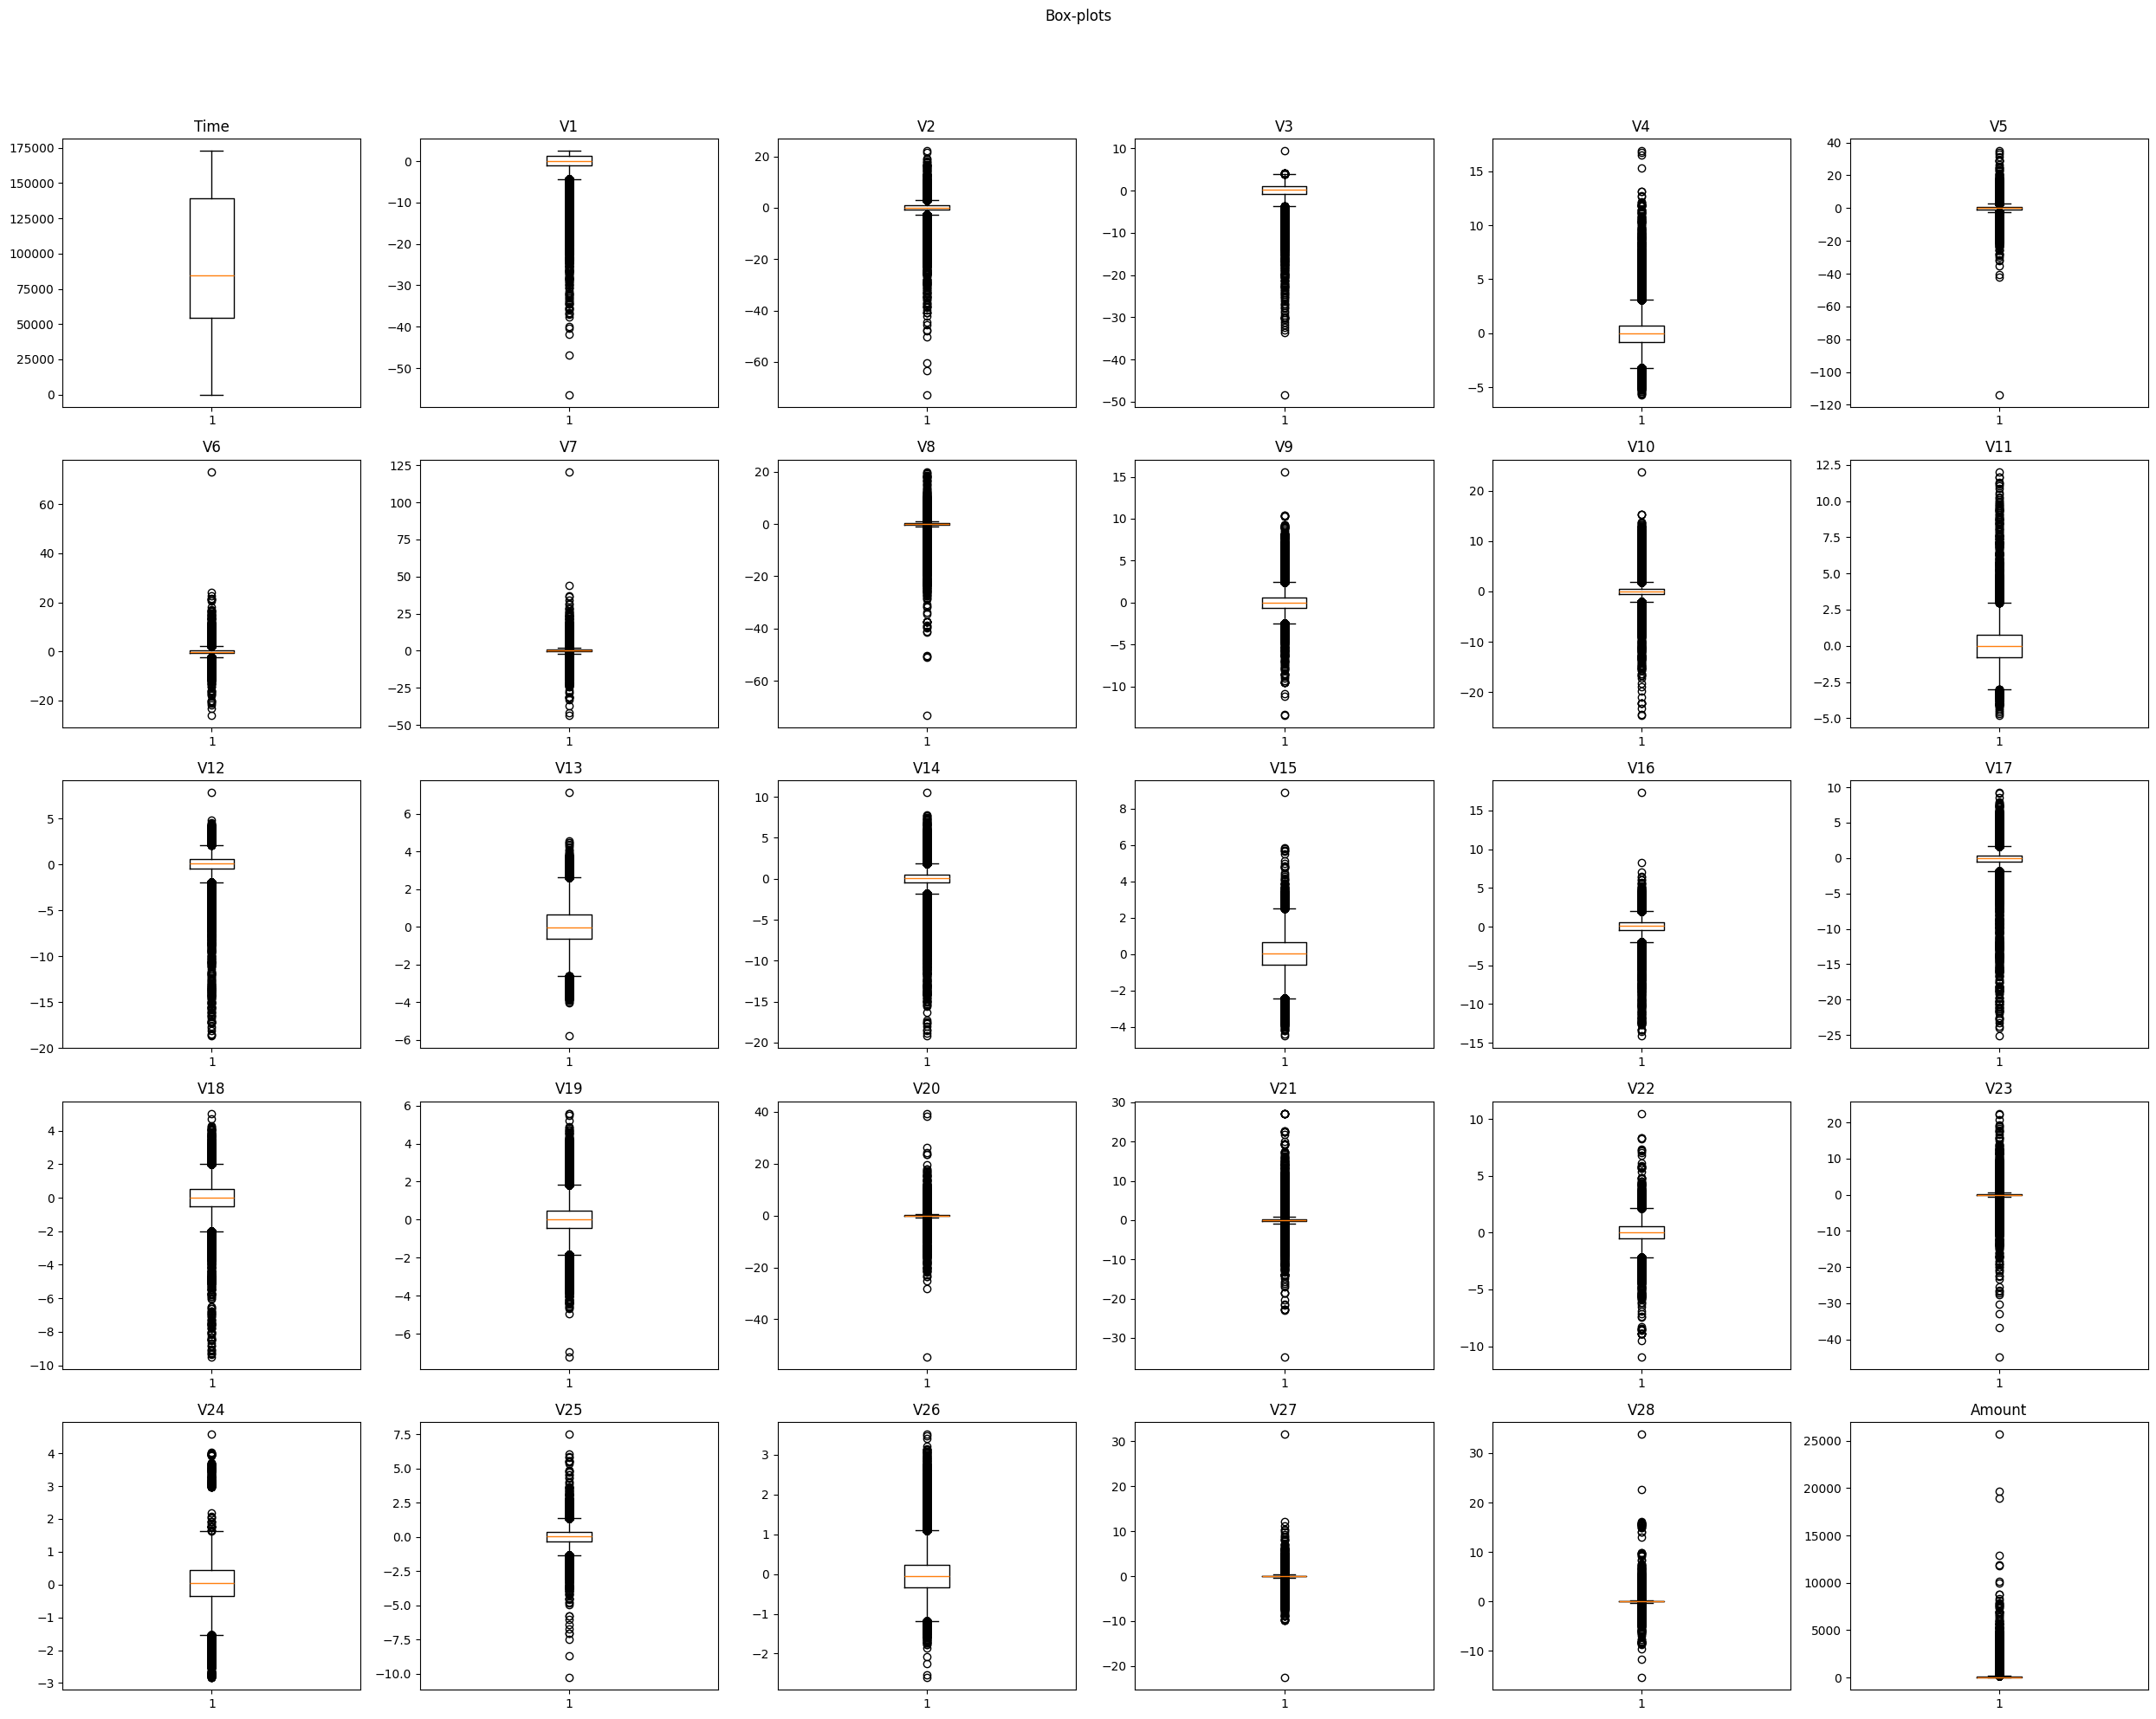

In [10]:
fig, axes = plt.subplots(5, 6, figsize=(25, 20)) # Changed to 5 rows and adjusted figsize
fig.suptitle('Box-plots', y=1.02) # Adjusted suptitle position slightly

row=0
col=0

for ax_idx, feature in enumerate(data_features.columns): # Iterate over column names for clarity
    axes[row, col].boxplot(data_features[feature])
    axes[row, col].set_title(feature) # Add title to each subplot
    col+=1
    if col > 5:
        row+=1
        col=0

# Hide any remaining empty subplots if the number of features is not a perfect multiple of 6
for i in range(len(data_features.columns), 5 * 6):
    row = i // 6
    col = i % 6
    fig.delaxes(axes[row, col])

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to accommodate suptitle
plt.show()

In [11]:
def outlier_iqr(data, col, threshold=1.5):
    IQR = data[col].quantile(0.75) - data[col].quantile(0.25)
    up_bound = data[col].quantile(0.75) + (IQR * threshold)
    low_bound = data[col].quantile(0.25) - (IQR * threshold)
    anomalies = pd.concat([data[col]>up_bound, data[col]<low_bound], axis=1).any(axis = 1)
    return anomalies, up_bound, low_bound

In [12]:
comparison_table, iqr_outliers = get_column_outliers(data_features, function=outlier_iqr)
anomalies_report(iqr_outliers)

Total number of outliers: 3578
Percentage of outliers:   1.26%


In [13]:
comparison_table

,upper_bound,lower_bound,anomalies_count,anomalies_percentage
Amount,1.365335e+03,-1.282570e+03,1635.0,0.574073
V27,3.004969e+00,-2.984763e+00,733.0,0.257367
V8,9.974907e+00,-9.856191e+00,654.0,0.229629
V28,2.440595e+00,-2.415275e+00,563.0,0.197678
V20,6.338761e+00,-6.417441e+00,536.0,0.188198
V23,5.718433e+00,-5.732638e+00,459.0,0.161162
V21,7.652276e+00,-7.694294e+00,428.0,0.150277
V2,2.604465e+01,-2.583948e+01,64.0,0.022471
V7,2.081165e+01,-2.079529e+01,63.0,0.022120
V17,1.630129e+01,-1.638537e+01,56.0,0.019662


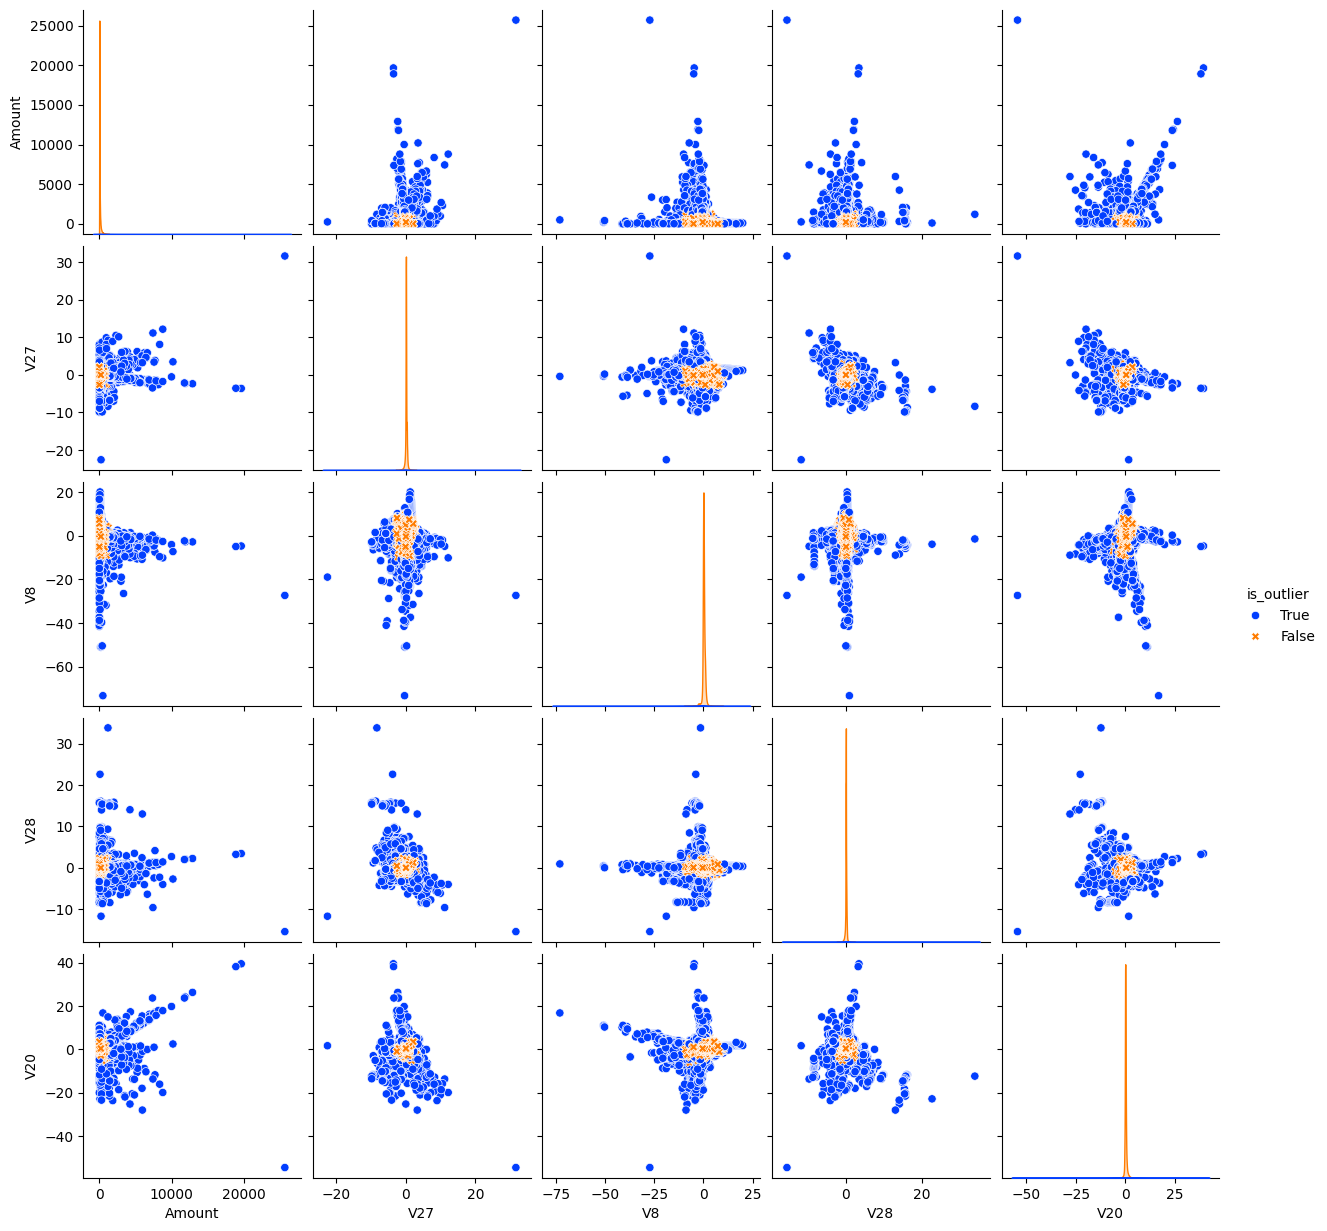

In [ ]:
high_corr = comparison_table.head(5).index.tolist()
labeled_data = data_features[high_corr].copy()
labeled_data['is_outlier'] = iqr_outliers

sns.pairplot(data=labeled_data, vars=high_corr,
             hue='is_outlier', hue_order=[True, False],
             markers=['X', 'o'], palette='bright');

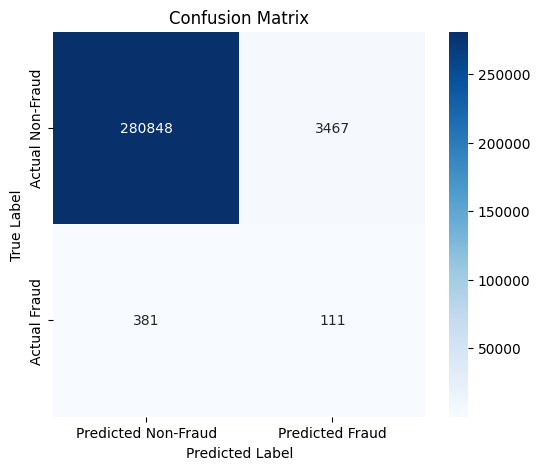


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    284315
           1       0.03      0.23      0.05       492

    accuracy                           0.99    284807
   macro avg       0.51      0.61      0.52    284807
weighted avg       1.00      0.99      0.99    284807



In [14]:
predicted_labels = iqr_outliers.astype(int)

true_labels = df['Class']

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Fraud', 'Predicted Fraud'],
            yticklabels=['Actual Non-Fraud', 'Actual Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print('\nClassification Report:')
print(classification_report(true_labels, predicted_labels))

# **Distance based**

In [17]:
from sklearn.base import BaseEstimator
from scipy.spatial.distance import cdist
from sklearn.preprocessing import RobustScaler

class DistanceOutliers(BaseEstimator):
    """
    -----------
    Parameters:

    - metric: string, default - euclidean
        metric to use for distance calculation (see scipy.spatial.distance.cdist)

    - percentile: float in range [0, 100]
        hyperparameter which sets the threshold for anomalies
    """
    def __init__(self, metric='euclidean', percentile=90):
        self.metric = metric
        self.percentile = percentile

    def fit(self, X):
        self.centroid = np.mean(X, axis=0).values.reshape(-1, 1).T
        distances_train = cdist(self.centroid, X, metric=self.metric).reshape(-1)
        self.threshold = np.percentile(distances_train, self.percentile)

    def predict(self, X):
        distances = cdist(self.centroid, X, metric=self.metric).reshape(-1)
        predictions = (distances > self.threshold).astype(int)
        return predictions

In [18]:
scaler = RobustScaler()
scaled_data = pd.DataFrame(
    data=scaler.fit_transform(data_features),
    columns=data_features.columns
)

In [25]:
euclidian_model = DistanceOutliers(metric='euclidean', percentile=99.8273)
euclidian_model.fit(scaled_data)
euclidian_outliers = euclidian_model.predict(scaled_data)
anomalies_report(euclidian_outliers)

Total number of outliers: 492
Percentage of outliers:   0.17%


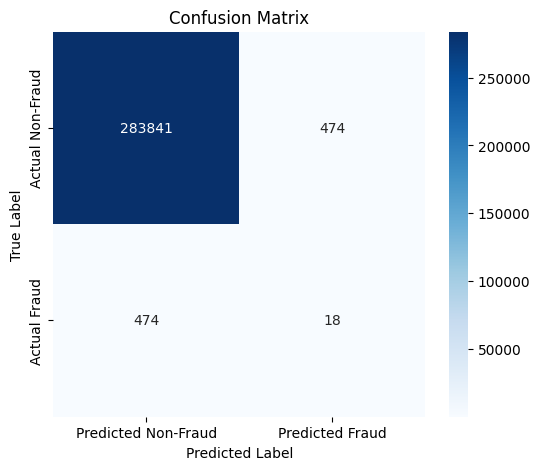


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.04      0.04      0.04       492

    accuracy                           1.00    284807
   macro avg       0.52      0.52      0.52    284807
weighted avg       1.00      1.00      1.00    284807



In [27]:
predicted_labels = euclidian_outliers.astype(int)

true_labels = df['Class']

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Fraud', 'Predicted Fraud'],
            yticklabels=['Actual Non-Fraud', 'Actual Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print('\nClassification Report:')
print(classification_report(true_labels, predicted_labels))

In [28]:
cityblock_model = DistanceOutliers(metric='cityblock', percentile=99.8273)
cityblock_model.fit(scaled_data)
cityblock_outliers = cityblock_model.predict(scaled_data)
anomalies_report(cityblock_outliers)

labeled_data = data_features.copy()
labeled_data['is_outlier'] = cityblock_outliers

Total number of outliers: 492
Percentage of outliers:   0.17%


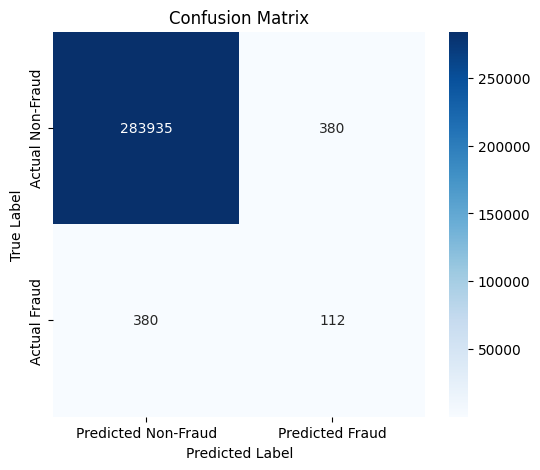


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.23      0.23      0.23       492

    accuracy                           1.00    284807
   macro avg       0.61      0.61      0.61    284807
weighted avg       1.00      1.00      1.00    284807



In [29]:
predicted_labels = cityblock_outliers.astype(int)

true_labels = df['Class']

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Fraud', 'Predicted Fraud'],
            yticklabels=['Actual Non-Fraud', 'Actual Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print('\nClassification Report:')
print(classification_report(true_labels, predicted_labels))

# **DBSCAN**

In [ ]:
from sklearn.cluster import DBSCAN

# для начала считаем все наблюдения аномальными
outlier_percentage = 1.

num_clusters = []
anomaly_percentage = []

# берем маленький эпсилон и начинаем увеличивать
eps = 0.01
eps_history = [eps]
while outlier_percentage>0.1727:
    model = DBSCAN(eps=eps).fit(scaled_data)
    labels = model.labels_
    num_clusters.append(len(np.unique(labels))-1)
    labels = np.array([1 if label == -1 else 0 for label in labels])
    # считаем текущий процент "шума"
    outlier_percentage = sum(labels==1) / len(labels)
    eps += 0.05
    eps_history.append(eps)
    anomaly_percentage.append(outlier_percentage)

model = DBSCAN(eps)
model.fit(scaled_data)
density_outlier = np.array([1 if label == -1 else 0 for label in model.labels_])

Воспользуйтесь стандартными методами оценки качества бинарной классификации (особенно хорошо подойдёт classification report и confusion matrix), и, используя предсказания моделей и переменную Class, проверьте, действительно ли модели справляются со своей задачей и насколько хорошо они это делают.


При помощи tSNE и/или UMAP, постройте сжатое представление исходных данных и проверьте, действительно ли аномалии лежат достаточно далеко от основной массы точек.